## 상태 저장하기 
- 챗봇은 외부 검색 도구를 활용하여 최신 정보를 제공할 수 있지만 이전 질문과 맥락을 기억할 수 없기 때문에 밀티턴 대화를 자연스럽게 이어가는데 한계가 있다. 
- 랭그래프에서는 그래프 상태 메모라 데이터베이스 같은 외부 저장소에 저장하고 이후 동일한 상태를 복원하여 지속적인 대화를 이어나갈 수 있는 기능을 제공한다. 
- 즉 그래프를 실행할 때 마다 상태를 새로 시작하는 것이 아니라 특정 세션이나 대화 스레드의 상태를 유지하고 관리 할 수 있다. 

In [3]:
from langgraph.checkpoint.memory import MemorySaver 

memory = MemorySaver()

In [10]:
from typing import Annotated 
from langchain_community.tools import DuckDuckGoSearchRun 
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START 
from langgraph.graph.message import add_messages 
from langgraph.prebuilt import ToolNode, tools_condition 

In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

In [11]:
tools = []
tool = DuckDuckGoSearchRun(max_result=2)
tools.append(tool)

llm = ChatOpenAI(
    base_url="http://localhost:1234/v1", 
    model = "gemma-4-e4b", 
    api_key="lm-studio")
    

llm_with_tools = llm.bind_tools(tools) 

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot) 

tool_node = ToolNode(tools = [tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition, 
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile(checkpointer=memory)


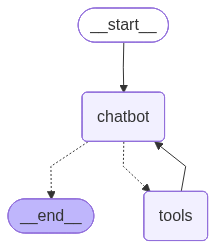

In [12]:
from IPython.display import Image, display 

display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
config = {"configurable" : {"thread_id" : 1 }}

In [19]:
user_input = "안녕 내 이름은 마이크야"

events = graph.stream(
    {"messages" : [("user", user_input)]} , config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕 내 이름은 마이크야
================================== Ai Message ==================================

다시 한번 인사해주셔서 감사합니다, 마이크님! 😊

저도 당신과 대화하게 되어 반갑습니다. 저는 언제든지 준비되어 있어요.

혹시 궁금한 점이나 도움이 필요한 일이 있으신가요? 편하게 말씀해주세요!


In [21]:
user_input = "내 이름 기억 하니?"

events = graph.stream(
    {"messages" : [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름 기억 하니?
================================== Ai Message ==================================

네, 기억하고 있습니다! 당신의 이름은 **마이크**시죠? 😊


In [23]:
events = graph.stream(
    {"messages" : ["user", user_input]}, 
    {"configurable" : {"thread_id":"2"}}, 
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름 기억 하니?
================================== Ai Message ==================================

죄송하지만, 저는 사용자의 이름을 따로 기억하고 있지는 않습니다. 혹시 다시 말씀해 주시겠어요? 😊


In [25]:
snap_shot = graph.get_state(config)

for k, v in enumerate(snap_shot):
    print(k, v)

0 {'messages': [HumanMessage(content=' ', additional_kwargs={}, response_metadata={}, id='fe0763e6-9eb7-400e-81c1-eeace259ecae'), AIMessage(content='How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 92, 'total_tokens': 147, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 44, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-e4b', 'system_fingerprint': 'google/gemma-4-e4b', 'id': 'chatcmpl-jlyph68rf2hazhc8visf', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f452e-c7e2-7652-a891-e5a0d04cfeff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 55, 'total_tokens': 147, 'input_token_details': {}, 'output_token_details': {'reasoning': 44}}), HumanMessage(content='안녕 내 이름은 마이크야', additional_kwargs={}, response_

In [28]:
graph = graph_builder.compile(
    checkpointer=memory, 
    interrupt_before=["tools"]
)
user_input = "지금 서울 날씨 어때?"
config = {"configurable" : {"thread_id" : "2"}}
events = graph.stream(
    {"messages" : [("user", user_input)]},
    config, 
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()



================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (188213236)
 Call ID: 188213236
  Args:
    query: 서울 날씨


In [29]:
# 그래프의 상태 스냅샵 가져와서 다음 실행될 노드 확인 

snap_shot = graph.get_state(config)
print(snap_shot.next)

('tools',)


In [32]:
from langchain_core.messages import AIMessage 
from langchain_core.messages import ToolMessage  

existing_message = snap_shot.values["messages"][-1] 
existing_message_id = existing_message.tool_calls[0]["id"]

answer = "서울의 날씨는 매우 흐려요."

new_messages = [
    ToolMessage(content=answer, tool_call_id=existing_message_id),
    AIMessage(content=answer) 
]

graph.update_state(
    config, 
    {"messages" : new_messages})

print("\n\n Last 2 message") 
print(graph.get_state(config).values["messages"][-2:])



 Last 2 message
[ToolMessage(content='서울의 날씨는 매우 흐려요.', id='6437a662-4577-442b-855c-572224e2ec9b', tool_call_id='188213236'), AIMessage(content='서울의 날씨는 매우 흐려요.', additional_kwargs={}, response_metadata={}, id='6c6089ea-6f51-4135-91cf-8c2348d092bc', tool_calls=[], invalid_tool_calls=[])]


In [ ]:
user_input = "지금 서울 날씨는 어때?"

config = {"configurable" : {"thread_id" : "3"}}

events = graph.stream(
    {"messages" : [("user", user_input)]} , 
    config, 
    stream_mode = "values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨는 어때?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (108004035)
 Call ID: 108004035
  Args:
    query: 서울 날씨


In [35]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call["args"]["query"] = "지금 경기도 날씨 어때?"
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id,
)

graph.update_state(config, {"messages": [new_message]})



{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17b668-cab3-6c84-8004-87237a6f6f5c'}}

In [36]:
print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])



Last 2 messages;
[HumanMessage(content='지금 서울 날씨는 어때?', additional_kwargs={}, response_metadata={}, id='373cdd9c-65bc-4ac4-ac22-640ca37af54d'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019f45bd-bbbf-7ea2-ace8-c63ccd3e08e0-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '지금 경기도 날씨 어때?'}, 'id': '108004035', 'type': 'tool_call'}], invalid_tool_calls=[])]
